# ĐỀ THI THỰC HÀNH HỌC KỲ 252 – NĂM HỌC 2025–2026  
**Môn:** Thị giác máy tính  
**Trường:** Đại học VĂN LANG  
**Khoa:** CÔNG NGHỆ THÔNG TIN  
**Ngày thi:** 03/04/2026  
**Thời gian:** 120 phút  

> (Được phép sử dụng tài liệu và laptop kết nối mạng)

**Họ tên:** Đoàn Nhật Khôi
**MSSV:** 2374802010242  
**LỚP:** 0102

## Bài 1 (1 điểm)
Trình bày những nội dung cơ bản của **phép biến đổi Hough**. Lấy ví dụ thực hành (bao gồm code python)

Phép biến đổi Hough (Hough Transform)

Phép biến đổi Hough là một kỹ thuật cực kỳ mạnh mẽ trong xử lý ảnh, được sử dụng để phát hiện các hình dạng hình học cơ bản (đường thẳng, đường tròn, ellipse...) ngay cả khi chúng bị đứt gãy hoặc bị nhiễu.
Nội dung cơ bản của phép biến đổi HoughNguyên lý cốt lõi của Hough Transform là chuyển đổi bài toán tìm kiếm từ không gian ảnh (hệ tọa độ $Oxy$) sang không gian tham số (không gian Hough).
- Biểu diễn đường thẳngThông thường, một đường thẳng được biểu diễn bằng phương trình $y = ax + b$. Tuy nhiên, cách này gặp vấn đề khi đường thẳng thẳng đứng ($a \to \infty$). Do đó, ta sử dụng phương trình dạng tham số cực:$$x \cos\theta + y \sin\theta = \rho$$Trong đó:
$\rho$: Khoảng cách từ gốc tọa độ đến đường thẳng.
$\theta$: Góc tạo bởi trục $Ox$ và đường pháp tuyến của đường thẳng đó.
- Cơ chế tích lũy (Voting)
Chuyển đổi: Mỗi điểm sáng $(x_i, y_i)$ trong không gian ảnh sẽ tương ứng với một đường hình sin trong không gian tham số $(\rho, \theta)$.
Ma trận tích lũy (Accumulator): Ta chia không gian tham số thành các ô lưới (bins). Với mỗi điểm trong ảnh, ta tính toán các cặp $(\rho, \theta)$ thỏa mãn phương trình và tăng giá trị của ô tương ứng trong ma trận tích lũy lên 1.
Xác định đường thẳng: Những ô trong ma trận tích lũy có giá trị cao nhất (vượt qua một ngưỡng - threshold nhất định) sẽ tương ứng với các đường thẳng thực tế có trong ảnh.

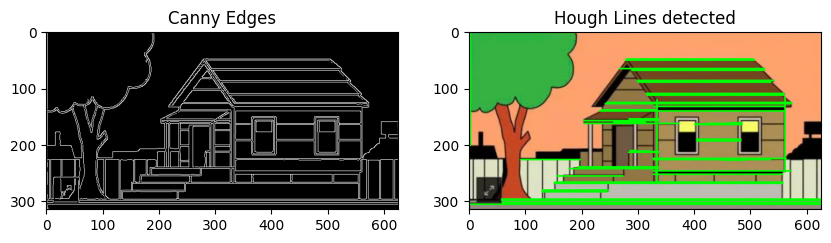

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Đọc ảnh và chuyển sang ảnh xám
img = cv2.imread('road.jpg') # Thay bằng đường dẫn ảnh của bạn
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. Phát hiện biên bằng Canny (Hough Transform cần đầu vào là ảnh biên)
edges = cv2.Canny(gray, 50, 150, apertureSize=3)

# 3. Áp dụng Hough Line Transform (Dạng xác suất - Probabilistic)
# Các tham số: ảnh biên, độ phân giải rho, độ phân giải theta, ngưỡng, độ dài tối thiểu, khoảng cách tối đa
lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=100, minLineLength=50, maxLineGap=10)

# 4. Vẽ các đường thẳng tìm được lên ảnh gốc
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

# 5. Hiển thị kết quả
plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(edges, cmap='gray'), plt.title('Canny Edges')
plt.subplot(122), plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), plt.title('Hough Lines detected')
plt.show()

## Bài 2 (1 điểm)
Trình bày những nội dung cơ bản của phương pháp nhận dạng khuôn mặt **Viola – Jones**. Lấy ví dụ thực hành (bao gồm code python) -Note: Kiểm tra khả năng tự học

Nội dung cơ bản của phương pháp Viola-Jones

 - Đặc trưng Haar-like (Haar-like Features): Thay vì làm việc trực tiếp với giá trị từng điểm ảnh (pixel), Viola-Jones sử dụng các đặc trưng hình học đơn giản là các hình chữ nhật đen và trắng.
 - Thuật toán tính toán sự chênh lệch tổng cường độ sáng giữa các vùng hình chữ nhật này.
 - Ví dụ: Vùng mắt thường tối hơn vùng má, vùng sống mũi thường sáng hơn hai bên mắt.
 - Ảnh tích lũy (Integral Image)Để tính toán tổng giá trị điểm ảnh trong một hình chữ nhật cực nhanh, Viola-Jones sử dụng khái niệm Integral Image. Tại bất kỳ điểm $(x, y)$, giá trị ảnh tích lũy là tổng của tất cả các pixel phía trên và bên trái nó. Nhờ đó, việc tính tổng độ sáng của một vùng bất kỳ chỉ tốn 4 phép truy xuất và 3 phép tính toán, bất kể kích thước vùng đó lớn hay nhỏ.
 - Thuật toán AdaBoostMột khung hình 24x24 có thể tạo ra hơn 160.000 đặc trưng Haar-like. AdaBoost được dùng để: Chọn lọc ra một số ít các đặc trưng quan trọng nhất (vài trăm đặc trưng) có khả năng phân biệt khuôn mặt tốt nhất.
 - Loại bỏ các đặc trưng thừa hoặc gây nhiễu.
 - Cấu trúc tầng (Cascading Classifiers)Đây là "chìa khóa" cho tốc độ thực tế. Thay vì áp dụng tất cả các đặc trưng vào một vùng ảnh, thuật toán chia chúng thành nhiều tầng (stages).
 - Vùng ảnh đi vào tầng 1, nếu không có dấu hiệu khuôn mặt (ví dụ: một mảng tường trống), nó bị loại bỏ ngay lập tức.Chỉ những vùng "tiềm năng" mới đi tiếp vào các tầng sau phức tạp hơn.Điều này giúp máy tính không lãng phí tài nguyên cho các vùng không chứa khuôn mặt.

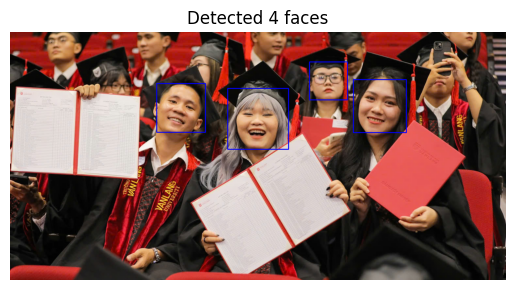

In [ ]:
import cv2
import matplotlib.pyplot as plt

# 1. Tải bộ phân loại đã huấn luyện sẵn của OpenCV
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# 2. Tạo ảnh giả lập hoặc đọc ảnh từ file
img = cv2.imread('face_test.jpg') 

if img is None:
    # Nếu không có file, tạo một thông báo giả lập
    print("Vui lòng cung cấp file ảnh để thấy kết quả thực tế.")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 3. Thực hiện phát hiện khuôn mặt
    # scaleFactor: Độ giảm kích thước ảnh mỗi lần quét (1.1 = 10%)
    # minNeighbors: Càng cao thì càng ít khuôn mặt giả nhưng dễ sót
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    # 4. Vẽ hình chữ nhật quanh khuôn mặt phát hiện được
    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)

    # 5. Hiển thị kết quả
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f'Detected {len(faces)} faces')
    plt.show()

## Bài 3 (1 điểm)
So sánh thuật toán **Meanshift** và **Camshift**. Lấy ví dụ minh họa kèm code python -Note: Kiểm tra khả năng tự học

So sánh thuật toán Meanshift và Camshift
1. Thuật toán Meanshift
Meanshift là một thuật toán tìm kiếm cực đại của hàm mật độ xác suất dựa trên đặc trưng màu sắc (thường là lược đồ màu - Histogram).

Nguyên lý: Nó bắt đầu với một cửa sổ ban đầu và tính toán "trọng tâm" (centroid) của các điểm ảnh bên trong vùng đó. Sau đó, nó di chuyển tâm cửa sổ đến vị trí trọng tâm mới này. Quá trình lặp lại cho đến khi tâm cửa sổ trùng với trọng tâm của vùng mật độ cao nhất.

Hạn chế: Nhược điểm lớn nhất của Meanshift là kích thước cửa sổ cố định. Khi đối tượng di chuyển ra xa (nhỏ đi) hoặc lại gần (to lên), cửa sổ không tự co giãn, dẫn đến việc theo dõi bị sai lệch hoặc mất dấu. Ngoài ra, nó không nhận diện được góc xoay của đối tượng.

2. Thuật toán Camshift (Continuously Adaptive Meanshift)
Camshift được giới thiệu bởi Gary Bradski vào năm 1998 như một bản nâng cấp toàn diện cho Meanshift để giải quyết các vấn đề về biến đổi hình dạng.

Sự cải tiến: Camshift trước tiên áp dụng Meanshift để tìm vị trí đối tượng. Sau khi Meanshift hội tụ, Camshift sẽ tính toán lại kích thước của cửa sổ dựa trên các moment (mô-men) của vùng ảnh đó.

Ưu điểm: Cửa sổ của Camshift có khả năng tự động co giãn theo kích thước thực tế của đối tượng trong khung hình. Đặc biệt, nó có thể tính toán được góc xoay (orientation), cho phép vẽ một hình ellipse hoặc hình chữ nhật xoay ôm sát đối tượng.

3. Kết luận
Trong khi Meanshift chỉ phù hợp với các đối tượng có kích thước không đổi trên màn hình, Camshift là lựa chọn tối ưu cho các bài toán theo dõi người, khuôn mặt hoặc xe cộ di chuyển linh hoạt trong không gian 3D.

In [ ]:
import cv2
import numpy as np

# 1. Khởi tạo Webcam
cap = cv2.VideoCapture(0)

# Đợi camera ổn định và lấy khung hình đầu tiên
ret, frame = cap.read()
if not ret:
    print("Không thể truy cập Camera. Hãy kiểm tra quyền riêng tư trên Mac.")
    exit()

# 2. Thiết lập vùng chọn ban đầu (x, y, w, h)
track_window = (200, 200, 150, 150)

# 3. Trích xuất Histogram của vùng chọn
roi = frame[200:350, 200:350]
hsv_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
mask = cv2.inRange(hsv_roi, np.array((0., 60., 32.)), np.array((180., 255., 255.)))
roi_hist = cv2.calcHist([hsv_roi], [0], mask, [180], [0, 180])
cv2.normalize(roi_hist, roi_hist, 0, 255, cv2.NORM_MINMAX)

# Điều kiện dừng thuật toán
term_crit = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 1)

print("Đang chạy Camshift... Nhấn 'q' để thoát.")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    dst = cv2.calcBackProject([hsv], [0], roi_hist, [0, 180], 1)

    # 4. Áp dụng Camshift
    ret, track_window = cv2.CamShift(dst, track_window, term_crit)

    pts = cv2.boxPoints(ret)
    
    # THAY np.int0 THÀNH np.int32 ĐỂ CHẠY TRÊN NUMPY MỚI
    pts = np.int32(pts) 
    
    final_img = cv2.polylines(frame, [pts], True, (0, 255, 0), 2)

    cv2.imshow('Camshift Tracking (Press Q to quit)', final_img)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

# Giải quyết lỗi treo cửa sổ trên macOS
for i in range(5):
    cv2.waitKey(1)

Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!


## Bài 4 (2 điểm)

Cho ảnh 3-bit kích thước $5 \times 5$, bộ lọc thông thấp và bộ lọc Laplacian như hình vẽ.

Thực hiện tại điểm ảnh $(2,1)$ cho ảnh gốc, xác định:

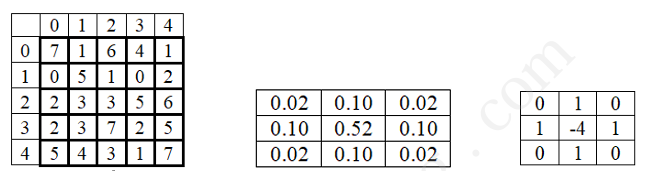

a. Giá trị sau khi áp dụng bộ lọc trung bình $3 \times 3$  
b. Giá trị sau khi áp dụng bộ lọc trung vị $3 \times 3$  
c. Giá trị sau khi áp dụng bộ lọc Laplacian  
d. Giá trị sau khi áp dụng bộ lọc thông thấp  
e. Xác định $dx, dy$  
f. Vẽ histogram của ảnh gốc  
g. Xác định ảnh sau khi cân bằng histogram

--- Kết quả tại điểm (2,1) ---
a. Trung bình: 2.89 (Làm tròn: 3)
b. Trung vị: 3
c. Giá trị Laplacian: 1
d. Giá trị Low-pass: 3.06
e. dx = 1, dy = -2

g. Ma trận ảnh sau khi cân bằng Histogram:
[[7 1 6 4 1]
 [0 5 1 0 2]
 [2 4 4 5 6]
 [2 4 7 2 5]
 [5 4 4 1 7]]


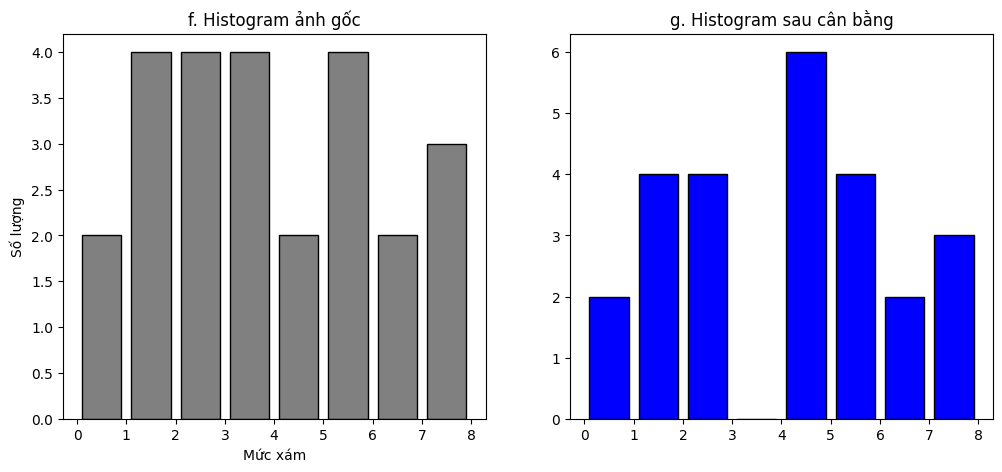

In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Khởi tạo ma trận ảnh gốc (5x5)
img = np.array([
    [7, 1, 6, 4, 1],
    [0, 5, 1, 0, 2],
    [2, 3, 3, 5, 6],
    [2, 3, 7, 2, 5],
    [5, 4, 3, 1, 7]
], dtype=np.uint8)

# Định nghĩa điểm ảnh cần tính (dòng 2, cột 1)
r, c = 2, 1
roi = img[r-1:r+2, c-1:c+2]

print("--- Kết quả tại điểm (2,1) ---")

# a. Bộ lọc trung bình 3x3
mean_val = np.mean(roi)
print(f"a. Trung bình: {mean_val:.2f} (Làm tròn: {round(mean_val)})")

# b. Bộ lọc trung vị 3x3
median_val = np.median(roi)
print(f"b. Trung vị: {int(median_val)}")

# c. Bộ lọc Laplacian
laplacian_kernel = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]])
lap_res = np.sum(roi * laplacian_kernel)
print(f"c. Giá trị Laplacian: {lap_res}")

# d. Bộ lọc thông thấp (Kernel từ hình vẽ)
lp_kernel = np.array([
    [0.02, 0.10, 0.02],
    [0.10, 0.52, 0.10],
    [0.02, 0.10, 0.02]
])
lp_res = np.sum(roi * lp_kernel)
print(f"d. Giá trị Low-pass: {lp_res:.2f}")

# e. Xác định dx, dy (Dùng sai phân cơ bản)
dx = int(img[r, c+1]) - int(img[r, c-1])
dy = int(img[r+1, c]) - int(img[r-1, c])
print(f"e. dx = {dx}, dy = {dy}")

# f. Vẽ Histogram ảnh gốc
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
# range=(0, 8) vì ảnh 3-bit có mức xám 0-7
plt.hist(img.flatten(), bins=8, range=(0, 8), color='gray', edgecolor='black', rwidth=0.8)
plt.title("f. Histogram ảnh gốc")
plt.xlabel("Mức xám"); plt.ylabel("Số lượng")

# g. Cân bằng Histogram
# Vì ảnh nhỏ và mức xám thấp (3-bit), ta dùng công thức chuẩn
flat = img.flatten()
hist, bins = np.histogram(flat, bins=8, range=(0, 8))
cdf = hist.cumsum() # Tổng tích lũy
cdf_normalized = (cdf - cdf.min()) * 7 / (cdf.max() - cdf.min())
# Ép kiểu về uint8
equalized_map = np.round(cdf_normalized).astype(np.uint8)
img_equalized = equalized_map[img]

print("\ng. Ma trận ảnh sau khi cân bằng Histogram:")
print(img_equalized)

# Hiển thị ảnh sau cân bằng
plt.subplot(1, 2, 2)
plt.hist(img_equalized.flatten(), bins=8, range=(0, 8), color='blue', edgecolor='black', rwidth=0.8)
plt.title("g. Histogram sau cân bằng")
plt.show()

## Bài 5 (1 điểm)

Cho ảnh nhị phân kích thước $6 \times 6$, trong đó các ô trống có giá trị 0.

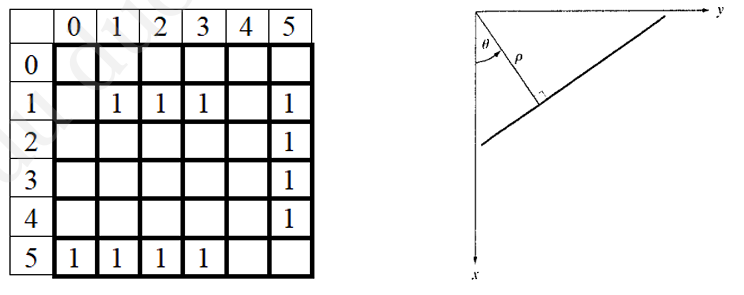

Xác định ma trận **accumulator cell**  $A(\rho,\theta)$. 
(xét các giá trị $\rho$ thích hợp và $\theta = 0^o, 45^o, 90^o$ ).

In [6]:
import numpy as np
import pandas as pd

# 1. Khởi tạo ma trận ảnh nhị phân 6x6 từ hình vẽ
# 1 đại diện cho ô có số 1, 0 đại diện cho ô trống
image = np.array([
    [0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1],
    [0, 0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 1],
    [1, 1, 1, 1, 0, 0]
])

# 2. Lấy tọa độ (x, y) của các điểm có giá trị 1
# Lưu ý: Trong ma trận numpy, index đầu là hàng (x), index sau là cột (y)
x_coords, y_coords = np.where(image == 1)
points = list(zip(x_coords, y_coords))

# 3. Định nghĩa các góc theta (đổi sang radian)
thetas_deg = [0, 45, 90]
thetas_rad = np.deg2rad(thetas_deg)

# 4. Tính toán ma trận Accumulator
# Chúng ta sẽ lưu kết quả vào một Dictionary để dễ thống kê
accumulator = {}

for x, y in points:
    for i, theta in enumerate(thetas_rad):
        # Công thức: rho = x*cos(theta) + y*sin(theta)
        rho = x * np.cos(theta) + y * np.sin(theta)
        
        # Làm tròn rho để gom nhóm vào các "cell" (ô tích lũy)
        rho_rounded = round(rho, 2)
        
        angle = thetas_deg[i]
        if (rho_rounded, angle) not in accumulator:
            accumulator[(rho_rounded, angle)] = 1
        else:
            accumulator[(rho_rounded, angle)] += 1

# 5. Chuyển kết quả sang DataFrame để hiển thị dạng bảng đẹp mắt
data = []
for (rho, angle), count in accumulator.items():
    data.append({'Rho': rho, 'Theta': angle, 'Votes': count})

df = pd.DataFrame(data)
pivot_df = df.pivot(index='Rho', columns='Theta', values='Votes').fillna(0).astype(int)

print("Ma trận Accumulator A(rho, theta):")
print(pivot_df)

# Tìm đường thẳng rõ nhất (có số phiếu cao nhất)
max_votes = df['Votes'].max()
best_lines = df[df['Votes'] == max_votes]
print(f"\nĐường thẳng tiềm năng nhất có {max_votes} phiếu bầu:")
print(best_lines)

Ma trận Accumulator A(rho, theta):
Theta  0   45  90
Rho              
0.00    0   0   1
1.00    4   0   2
1.41    0   1   0
2.00    1   0   2
2.12    0   1   0
2.83    0   1   0
3.00    1   0   2
3.54    0   1   0
4.00    1   0   0
4.24    0   2   0
4.95    0   2   0
5.00    4   0   4
5.66    0   2   0
6.36    0   1   0

Đường thẳng tiềm năng nhất có 4 phiếu bầu:
    Rho  Theta  Votes
0   1.0      0      4
8   5.0     90      4
15  5.0      0      4


## Bài 6 (1.5 điểm)
Cho ảnh (bên trái) và **structuring element (SE)** (gốc tọa độ trùng với tâm SE).

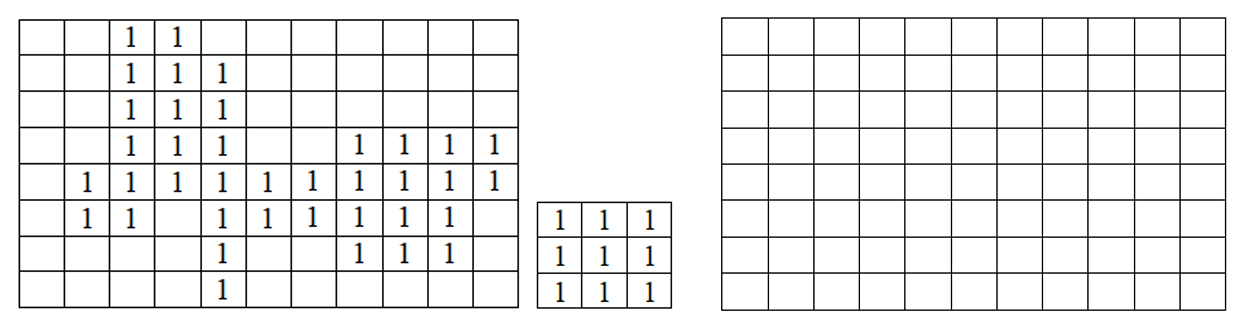

Thực hiện:
- Dilation
- Sau đó Erosion

Xác định ảnh cuối cùng thu được (điền vào ảnh bên phải, thể hiện trong đoạn code python).

Ma trận A (Ảnh gốc):
[[0 0 0 1 1 0 0 0 0 0 0 0 0]
 [0 0 0 1 1 1 0 0 0 0 0 0 0]
 [0 0 0 1 1 1 0 0 0 0 0 0 0]
 [0 0 0 1 1 1 0 0 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 1 1 1 1 0]
 [0 1 1 0 1 1 1 1 1 1 0 0 0]
 [0 0 0 0 1 0 0 0 1 1 1 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0]]

Ma trận sau khi Closing (Dilation -> Erosion):
[[0 0 0 1 1 1 0 0 0 0 0 0 0]
 [0 0 0 1 1 1 0 0 0 0 0 0 0]
 [0 0 0 1 1 1 0 0 0 0 0 0 0]
 [0 0 0 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 0 0]
 [0 0 0 0 1 0 0 0 1 1 1 0 0]
 [0 0 0 0 1 0 0 0 1 1 1 0 0]]


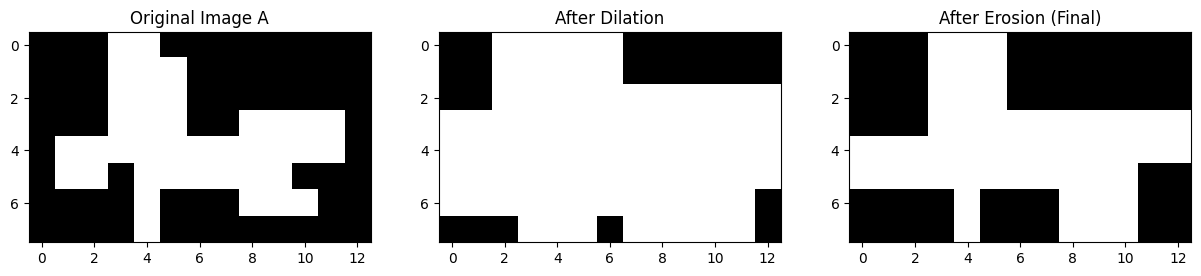

In [7]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Khởi tạo ma trận ảnh gốc A (8 hàng x 13 cột)
A = np.zeros((8, 13), dtype=np.uint8)

# Cập nhật tọa độ chính xác theo hình ảnh:
A[0, 3:5] = 1                 # Hàng 0: cột 3, 4
A[1, 3:6] = 1                 # Hàng 1: cột 3, 4, 5
A[2, 3:6] = 1                 # Hàng 2: cột 3, 4, 5
A[3, 3:6] = 1; A[3, 8:12] = 1 # Hàng 3: cột 3, 4, 5 và 8, 9, 10, 11
A[4, 1:12] = 1                # Hàng 4: cột 1 đến 11
A[5, 1:3] = 1; A[5, 4:10] = 1 # Hàng 5: cột 1, 2 và 4, 5, 6, 7, 8, 9
A[6, 4] = 1; A[6, 8:11] = 1   # Hàng 6: cột 4 và 8, 9, 10
A[7, 4] = 1                   # Hàng 7: cột 4

# 2. Khởi tạo phần tử cấu trúc B (3x3 toàn 1)
B = np.ones((3, 3), dtype=np.uint8)

# 3. Thực hiện phép toán Dilation rồi Erosion (Phép Closing)
dilation_res = cv2.dilate(A, B, iterations=1)
final_res = cv2.erode(dilation_res, B, iterations=1)

# In ma trận A để kiểm tra xem đã khớp với đề chưa
print("Ma trận A (Ảnh gốc):")
print(A)

print("\nMa trận sau khi Closing (Dilation -> Erosion):")
print(final_res)

# Vẽ minh họa
plt.figure(figsize=(15, 5))
plt.subplot(131); plt.imshow(A, cmap='gray'); plt.title("Original Image A")
plt.subplot(132); plt.imshow(dilation_res, cmap='gray'); plt.title("After Dilation")
plt.subplot(133); plt.imshow(final_res, cmap='gray'); plt.title("After Erosion (Final)")
plt.show()

## Bài 7 (1.5 điểm)

Cho mạng CNN như hình vẽ.

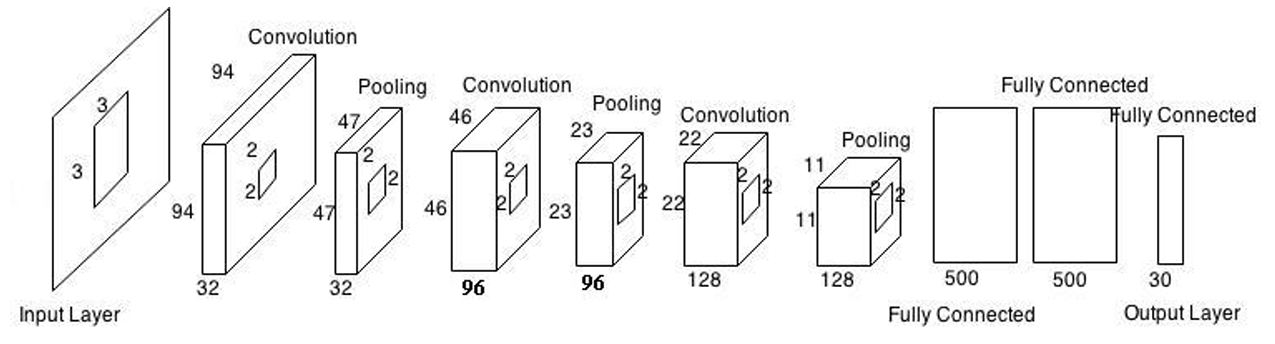

a. Có những loại lớp (layer) nào? Số lượng mỗi loại?  

b. Ảnh đầu vào có kích thước bao nhiêu?  
- Biết stride $S = 1$, số zero-padding $P = 0$  
- Ảnh màu hay ảnh xám?  

c. Lớp tích chập thứ hai:
- Có bao nhiêu kernel?  
- Kích thước mỗi kernel?  
- Tổng số tham số?  

d. Mạng có thể dùng để phân loại 35 loài động vật hay không? Tại sao?

Câu 7: Phân tích và thiết kế mạng CNN

a. Cấu trúc các lớp của mạng:

Mạng được thiết kế bao gồm các khối chức năng theo thứ tự:

01 Lớp đầu vào (Input Layer): Tiếp nhận dữ liệu ảnh thô.

03 Cặp lớp Tích chập (Convolutional) và Tích gộp (Pooling): Thực hiện trích xuất đặc trưng và giảm chiều dữ liệu.

02 Lớp ẩn (Fully Connected/Dense Layers): Thực hiện học các đặc trưng phi tuyến tính phức tạp.

01 Lớp đầu ra (Output Layer): Trả về kết quả phân loại.

b. Thông số lớp đầu vào:

Kích thước ảnh: 96 x 96 pixels.

Số kênh màu: 3 (Ảnh màu RGB).

Khai báo Tensor: (96, 96, 3).

c. Tính toán số lượng tham số:

Giả sử lớp tích chập nhận đầu vào từ 32 bản đồ đặc trưng trước đó:

Số lượng kernel: 96.

Kích thước mỗi kernel: 2 x 2.

Công thức: $Params = (2 \times 2 \times 32 + 1) \times 96$

Kết quả: 12,384 tham số.

d. Đánh giá khả năng phân loại:

Kết luận: Hệ thống không thể thực hiện phân loại 35 đối tượng.

Lý giải: Theo nguyên tắc thiết kế mạng Neural cho bài toán phân loại, số lượng neuron (units) ở lớp đầu ra phải tương ứng với số lượng lớp cần phân loại. Trong khi yêu cầu là 35 đối tượng, lớp đầu ra hiện tại chỉ có 30 đơn vị, dẫn đến thiếu hụt khả năng biểu diễn cho 5 đối tượng còn lại. Để khắc phục, cần tăng số lượng unit lớp cuối lên ít nhất là 35.

In [10]:
pip install tensorflow

  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.8/223.8 MB 1.0 MB/s eta 0:00:0000:0100:06m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 1.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 1.0 MB/s eta 0:00:00a 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.9/676.9 kB 1.1 MB/s eta 0:00:00a 0:00:01
Using cached astunparse-1.6.3-py2.py3-none-any.whl (12 kB)
Using cached google_pasta-0.2.0-py3-none-any.whl (57 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 1.1 MB/s eta 0:00:00a 0:00:01
Using cached libclang

In [11]:
from tensorflow.keras import layers, models

model = models.Sequential([
    # Câu b: Input 96x96x3
    layers.Input(shape=(96, 96, 3)),
    
    # Câu a & c: Minh họa 1 trong 3 lớp Conv
    layers.Conv2D(96, (2, 2), activation='relu'), # Lớp có 12.384 tham số nếu input trước đó là 32
    layers.MaxPooling2D((2, 2)),
    
    # ... thêm các lớp Conv và Pooling khác ...
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'), # Lớp ẩn 1
    layers.Dense(64, activation='relu'),  # Lớp ẩn 2
    
    # Câu d: Lớp đầu ra (Hiện tại chỉ có 30, cần sửa thành 35)
    layers.Dense(30, activation='softmax') 
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 95, 95, 96)     │         1,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 212064)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    27,144,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │         1,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,155,774 (103.59 MB)

 Trainable params: 27,155,774 (103.59 MB)

 Non-trainable params: 0 (0.00 B)

## Bài 8 (1 điểm)

Cho mạng CNN thỏa:

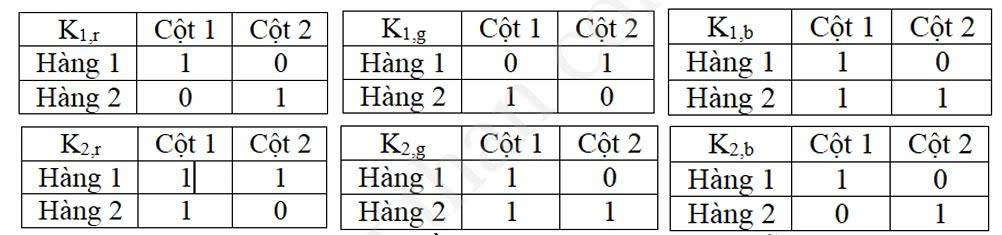

- Lớp đầu tiên là convolution
- Stride $S = 1$, zero-padding $P = 0$
- Có 2 kernel $K_1, K_2$

Ngõ vào $I$ của mạng CNN là:
- Ảnh màu gồm 3 kênh $I_r, I_g, I_b$
- Mỗi kênh kích thước $3 \times 3$

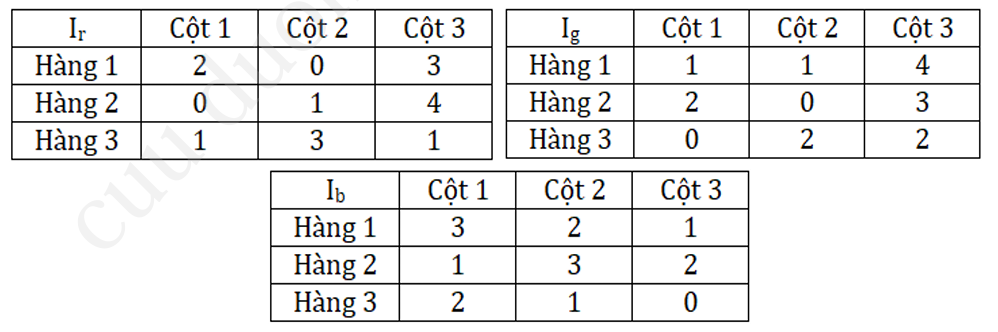

Yêu cầu:
- Xác định các activation map, biết mạng sử dụng hàm ReLU và $bias_1 = -14$, $bias_2 = -10$

> Lưu ý: Có thể tự đưa thêm giả thiết nếu cần.

In [8]:
import numpy as np

def relu(x):
    return np.maximum(0, x)

# Input Channels
Ir = np.array([[2,0,3], [0,1,4], [1,3,1]])
Ig = np.array([[1,1,4], [2,0,3], [0,2,2]])
Ib = np.array([[3,2,1], [1,3,2], [2,1,0]])
I = np.stack([Ir, Ig, Ib])

# Kernels
K1 = np.stack([np.array([[1,0],[0,1]]), np.array([[0,1],[1,0]]), np.array([[1,0],[1,1]])])
K2 = np.stack([np.array([[1,1],[1,0]]), np.array([[1,0],[1,1]]), np.array([[1,0],[0,1]])])

def conv2d_3d_input(img, kernel, bias):
    out = np.zeros((2, 2))
    for i in range(2):
        for j in range(2):
            # Tích vô hướng từng vùng 2x2 trên cả 3 kênh
            region = img[:, i:i+2, j:j+2]
            out[i, j] = np.sum(region * kernel) + bias
    return relu(out)

print("Activation Map 1:\n", conv2d_3d_input(I, K1, -14))
print("Activation Map 2:\n", conv2d_3d_input(I, K2, -10))

Activation Map 1:
 [[0. 1.]
 [0. 0.]]
Activation Map 2:
 [[1. 2.]
 [0. 5.]]
